In [395]:
# Initial setup

import pandas as pd
import numpy as np

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.0f}".format

In [396]:
# The data cleaning process in the previous step.
# We put them into a single function.

In [397]:
def clean_up_raw_data(year:int):
    df = pd.read_csv(f"./data/raw/generation_tech_{year}.csv")
    # Clean up generation values
    df['Generation (MW)'] = pd.to_numeric(df['Generation (MW)'], errors='coerce')
    # Extract date from MTU
    df['start_time'] = df['MTU (CET/CEST)'].str.split(' - ').str[0]
    df['date'] = df['start_time'].str.split(' ').str[0]
    df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
    df = df[['date','Production Type','Generation (MW)']]
    df = df.rename(columns={
        'Production Type':'tech',
        'Generation (MW)':'gen',
    })
    return df

In [398]:
df = clean_up_raw_data(year=2015)
df.sample(5)

,date,tech,gen
37876,2015-04-29,Fossil Gas,"1,032"
94544,2015-10-17,Hydro Pumped Storage,518
24941,2015-11-06,Fossil Brown coal/Lignite,NaN
146371,2015-09-16,Other renewable,NaN
93980,2015-09-23,Hydro Pumped Storage,728


In [399]:
# The data loses resolution. We no longer see the generation by hour, but for our purpose, this is fine as we are much more concerned about the monthly / yearly trend.
# We want to know the Daily Average Share of Generation by each tech per day
# We do this by calculating the total Electricity produced by each tech per day / Electricity produce by all techs per day

In [400]:
df['daily_electricity_by_gen'] = (
    df.groupby(['date', 'tech'])['gen']
      .transform('sum')
)

df['daily_electricity'] = (
    df.groupby(['date'])['gen']
      .transform('sum')
)

In [401]:
df['daily_avg_share_gen'] = df['daily_electricity_by_gen'] / df['daily_electricity']

# Use 4 decimal places for viewing the daily_avg_share_gen column
df['daily_avg_share_gen_view_only'] = df['daily_avg_share_gen'].map(
    lambda x: f"{x:,.4f}" if x < 1 else f"{x:,.2f}"
)
df

,date,tech,gen,daily_electricity_by_gen,daily_electricity,daily_avg_share_gen,daily_avg_share_gen_view_only
0,2015-01-01,Biomass,193,"4,813","1,725,680",0,0.0028
1,2015-01-01,Biomass,193,"4,813","1,725,680",0,0.0028
2,2015-01-01,Biomass,193,"4,813","1,725,680",0,0.0028
3,2015-01-01,Biomass,193,"4,813","1,725,680",0,0.0028
4,2015-01-01,Biomass,193,"4,813","1,725,680",0,0.0028
...,...,...,...,...,...,...,...
183955,2015-12-31,Wind Onshore,"3,140","82,454","1,516,852",0,0.0544
183956,2015-12-31,Wind Onshore,"3,252","82,454","1,516,852",0,0.0544
183957,2015-12-31,Wind Onshore,"3,196","82,454","1,516,852",0,0.0544
183958,2015-12-31,Wind Onshore,"2,840","82,454","1,516,852",0,0.0544


In [402]:
# We're also interested in knowing the Average power by each tech per day, as well as the level of variance (determined by Coefficient of Variance, COV)
# We'll create a separate table, grouping each tech and date (remember each gen unit is MW)

In [403]:
g = df.groupby(['date','tech']).agg(
    avg_gen=('gen','mean'),
    std_gen=('gen','std'),
).reset_index()

g['cov'] = g['std_gen'] / g['avg_gen'] * 100

In [404]:
# combine the two tables together by date and tech
# Before that, we have to group by date and tech for the first dataset

g2 = df.groupby(['date','tech']).agg(
    daily_electricity_by_gen=('daily_electricity_by_gen','mean'),
    daily_avg_share_gen=('daily_avg_share_gen','mean')
).reset_index()

g2

,date,tech,daily_electricity_by_gen,daily_avg_share_gen
0,2015-01-01,Biomass,"4,813",0
1,2015-01-01,Energy storage,0,0
2,2015-01-01,Fossil Brown coal/Lignite,0,0
3,2015-01-01,Fossil Coal-derived gas,0,0
4,2015-01-01,Fossil Gas,"58,190",0
...,...,...,...,...
7660,2015-12-31,Other renewable,0,0
7661,2015-12-31,Solar,"6,461",0
7662,2015-12-31,Waste,"2,225",0
7663,2015-12-31,Wind Offshore,0,0


In [405]:
m = pd.merge(g,g2,'left',['date','tech'])

In [406]:
# We are also interested in the daily power production

g = df.groupby(['date']).agg(daily_electricity=('daily_electricity','mean')).reset_index()

In [407]:
# Daily electricity production

# Over each day in 2015, what is the total amount of electrical energy that was produced by the French grid?

# Seasonality is apparent here. Weekly cycle is apparent throughout - higher power demand in the weekdays, lower in the weekend.
# Base load changes by season. Winter months, power demand is highest. By April, temperatures are milder. Cooler summers, although power usage increases slightly in June, demand for cooling.
# Returning to winter, colder months

In [408]:
import plotly.express as px

color_map = {
    "Solar": "#FDB813",
    "Wind Onshore": "#1f77b4",
    "Nuclear": "#2ca02c",
    "Coal": "#7f7f7f",
    "Hydro Run-of-river and pondage": "#00a58c",
    "Hydro Water Reservoir": "#28d3f5",
    "Fossil Gas": "#d62728",
    "Fossil Oil": "#896060",
    "Fossil Hard coal": "#000000",
}

fig = px.line(
    g,
    x="date",
    y="daily_electricity",
    markers=False,
    color_discrete_map=color_map,
    labels={
        'daily_electricity':'Electricity generation (MWh)',
        'date':'Date',
    }
)
fig.update_layout(title="Daily electricity generation (MWh) in 2015")
fig.show()

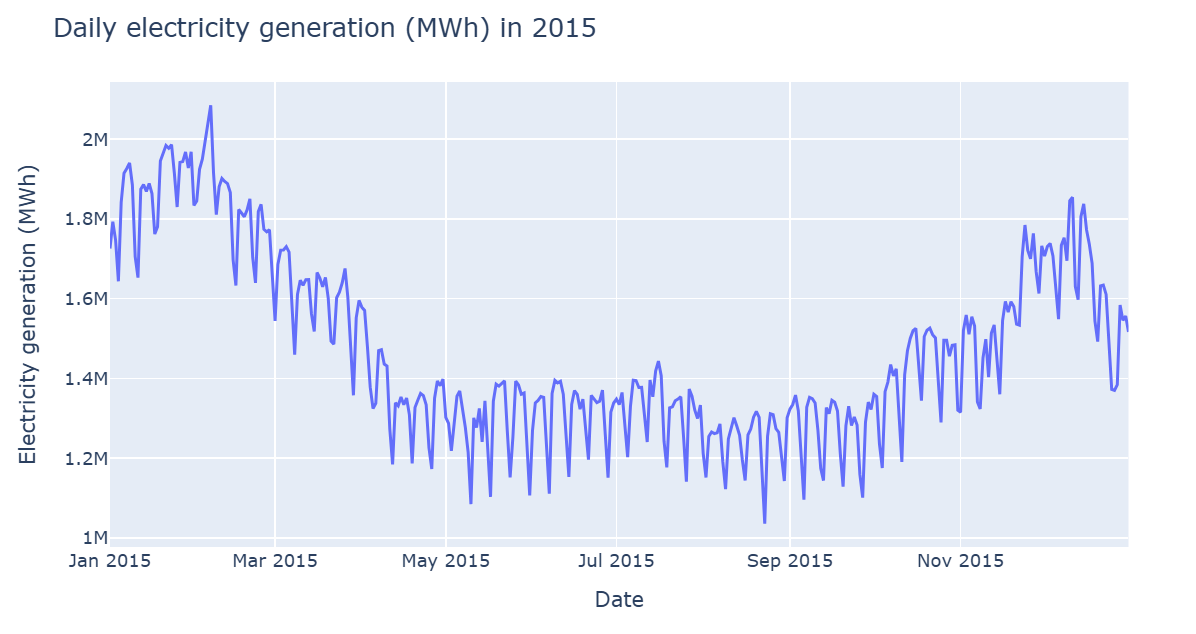

In [409]:
# How much electricity is produced daily by each technology?

# Nuclear produces the most electricity at a peak of 1.45 TWh in 2015.
# The most significant power producer 
# Natural gas and hydro reservoirs support with peak loads in winter months, but rarely used in spring and autum.
# Hydro run-of-river shows seasonal variance; higher in springtime due to melting ice and snow.

In [410]:
df_m = m.copy()
fig = px.line(
    df_m,
    x="date",
    y="daily_electricity_by_gen",
    color="tech",
    markers=False,
    color_discrete_map=color_map,
    labels={
        'daily_electricity_by_gen':'Daily generation (MWh)',
        'date':'Date',
    }
)
fig.update_layout(title="Daily electricity generation (MWh) by tech in 2015")
fig.show()


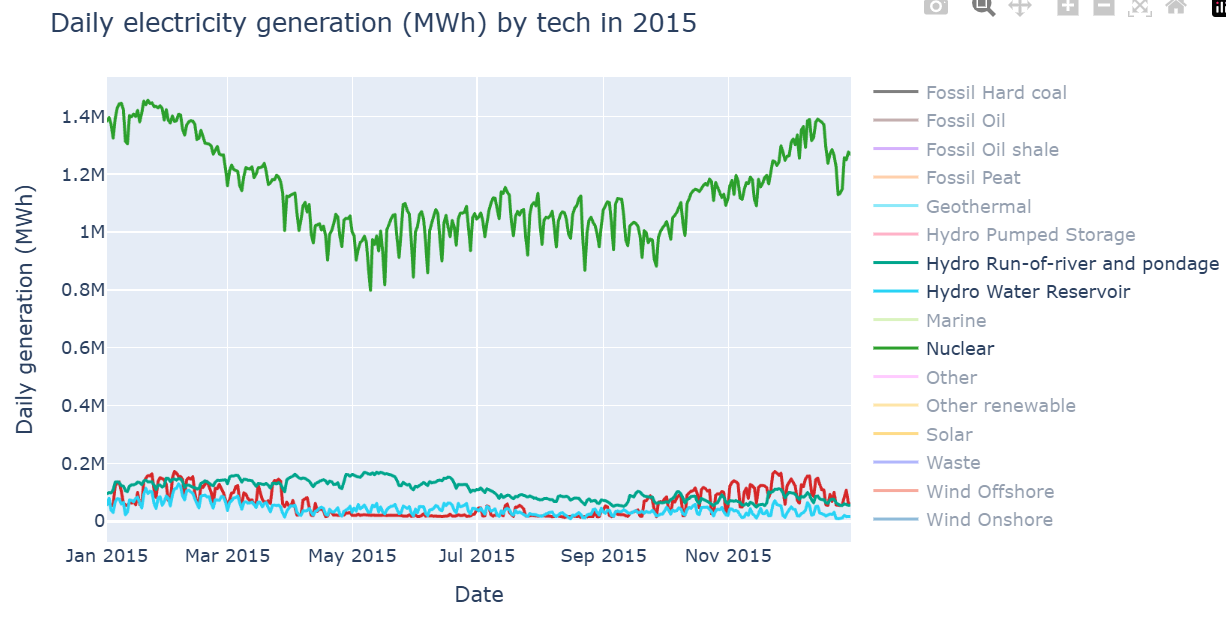

In [411]:
# In terms of share of power production, what does it look like for each tech?

# Nuclear = above 67%
# Hydro total = up to 20%
# Less than 15% of power comes from fossil fuel

In [412]:
df_m = m.copy()
fig = px.line(
    df_m,
    x="date",
    y="daily_avg_share_gen",
    color="tech",
    markers=False,
    color_discrete_map=color_map,
    labels={
        'daily_avg_share_gen':'Share of total generation (1 = 100%)',
        'date':'Date',
    }
)
fig.update_layout(title="Daily average share of total generation by tech in 2015")
fig.show()


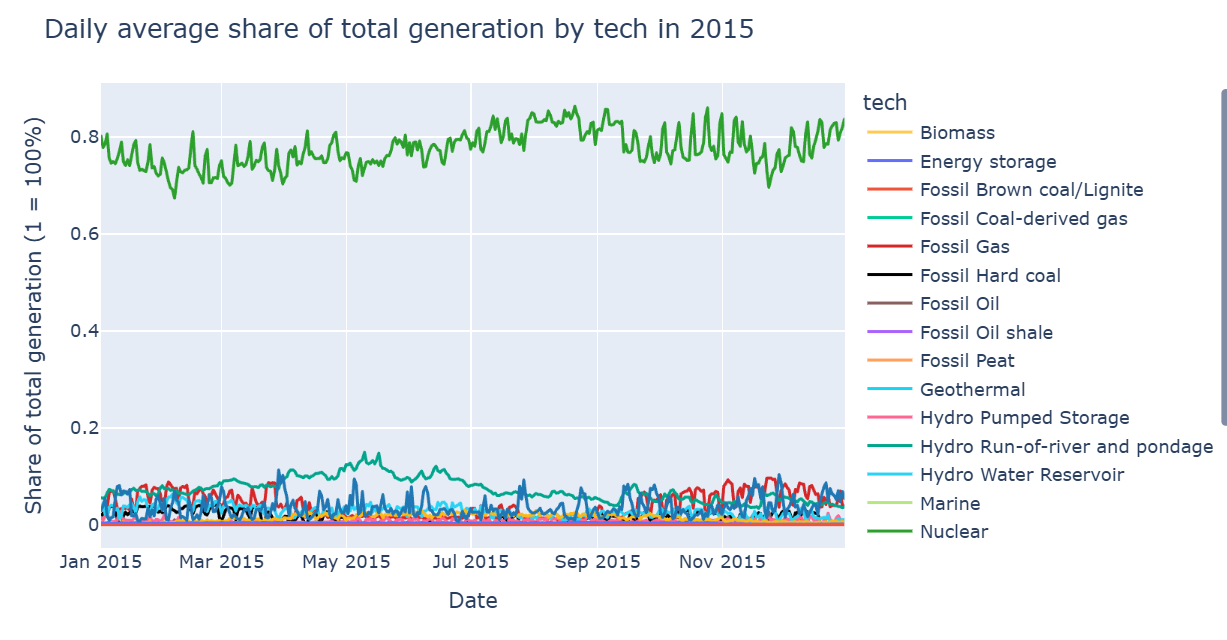

In [ ]:
# Coefficient of variance (COV) tells us how flexible or variable that type of power producer is.
# This helps us identify which generators tend to run consistently, and which one depends on natural conditions or is used to balance supply / demand.
# Lowest COV (generators with the most stable outputs) = Nuclear at 0 - 10, Biomass at 0 - 5
# Medium COV = Fossil Gas at 0 - 40, Fossil oil at 0 - 90, Coal at 0 - 50 
# High COV = Solar 107 - 169, Hydro reservoir at 25 - 100, Wind onshore at 25 - 100, Some Coal units during summer (most likely capacity provider / balancing mFRR)

# Solar has high COV because output depends on the sine of the incident sunlight.
# During winter, avg solar power is lower than in summer, creating a flatter solar generation curve.

In [413]:
fig = px.line(
    df_m,
    x="date",
    y="cov",
    color="tech",
    markers=False,
    color_discrete_map=color_map,
    labels={
        'cov':'Production variance (% of mean)',
        'date':'Date',
    }
)
fig.update_layout(title="Daily production variance by tech in 2015")
fig.show()

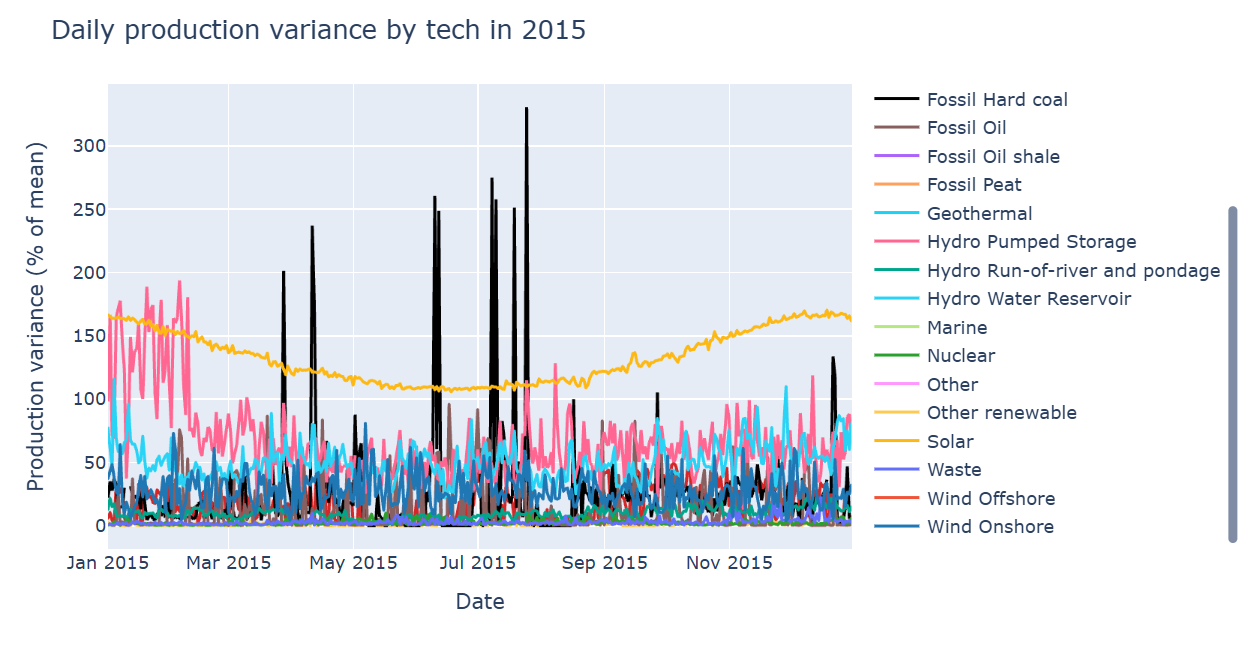